## Setup

### Load Modules

In [24]:
import os
import sys
from pathlib import Path
from typing import Callable, NamedTuple, List
from dataclasses import dataclass
import functools

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import sklearn as sk
import torch
from tqdm import tqdm
import tangram as tg
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics import mean_squared_error

ModuleNotFoundError: No module named 'tangram'

### Data Utils

In [2]:
class Reconstruction_Result(NamedTuple):
    """
    A class to store the original and predicted gene counts along with methods
    to process and compute metrics based on those counts.

    Attributes:
        original_counts (pd.DataFrame): The original gene counts from the query data.
        predicted_counts (pd.DataFrame): The predicted gene counts from the gene prediction model.
    """

    original_counts: pd.DataFrame
    predicted_counts: pd.DataFrame

    @classmethod
    def from_gene_predictor(
        cls,
        adata_query: ad.AnnData,
        compidx: np.ndarray[str],
        subidx: np.ndarray[str],
        gene_predictor: Callable[[ad.AnnData, np.ndarray[str], np.ndarray[str]], np.ndarray],
    ) -> "Reconstruction_Result":
        """
        Creates a Reconstruction_Result instance from a gene prediction model.

        Args:
            adata_query (ad.AnnData): The AnnData object containing the query data (e.g., query spatial data).
            compidx (np.ndarray[str]): A list of gene identifiers to be predicted.
            gene_predictor (Callable[[ad.AnnData, np.ndarray[str]], np.ndarray]): A function that predicts gene counts
                based on the query AnnData object and the list of gene identifiers. It should return a NumPy array
                of predicted counts.

        Returns:
            Reconstruction_Result: A new instance containing the original and predicted gene counts as DataFrames.
        """
        return Reconstruction_Result( 
            pd.DataFrame(
                data=adata_query[:, compidx].X,
                columns=compidx
            ),
            pd.DataFrame(
                data=gene_predictor(adata_query, compidx, subidx),
                columns=compidx
            )
        )

    def compute_correlation(
        self,
        correlation_func: Callable[[np.ndarray, np.ndarray], float],
    ) -> float:
        """
        Computes the correlation between the original and predicted gene counts.

        Args:
            correlation_func (Callable[[np.ndarray, np.ndarray], float]): A function that computes the correlation
                between two NumPy arrays. It should return a single floating-point value representing the correlation.

        Returns:
            float: The computed correlation between the original and predicted gene counts.
        """
        return correlation_func(
            self.original_counts.values,
            self.predicted_counts.values
        )



### NMF Utils

In [3]:
def prepare_H_init(
    adata_reference: ad.AnnData,
    shared_genes: np.ndarray,
    n_components: int
) -> pd.DataFrame:

    _, H_init, _ = non_negative_factorization(
        adata_reference[:, shared_genes].X.toarray(), 
        n_components=n_components
    )

    return pd.DataFrame(
        data=H_init,
        columns=shared_genes
    )

def predict_genes_nmf(
    adata_query: sc.AnnData, 
    H_init: pd.DataFrame,
    compidx: np.ndarray[str],
    subidx: np.ndarray[str],
) -> np.ndarray:


    W, _, _ = non_negative_factorization(
        adata_query[:, subidx].X, 
        H=H_init[subidx].values,
        init="custom", 
        update_H=False,
        n_components=H_init.shape[0],
    )
    return W @ H_init[compidx].values

### Autoencoder Utils

#### Architecture

In [193]:
def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_backward(dZ, Z):
    dZ[Z <= 0] = 0
    return dZ

@dataclass
class LinearLayer:
    W: np.ndarray
    b: np.ndarray

    def __post_init__(self):
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_cache = None  

    def forward(self, Z):
        self.input_cache = Z 
        return (Z @ self.W) + self.b
    
    def backward(self, dZ):
        dW = self.input_cache.T @ dZ  
        db = np.sum(dZ, axis=0, keepdims=True)  

        dZ_prev = dZ @ self.W.T 

        self.dW = dW
        self.db = db

        return dZ_prev 
    
    def __call__(self, Z):
        return self.forward(Z)

class Model:
    def __init__(self, n_input, n_latent, n_output):
        self.fc1 = LinearLayer(
            W=np.random.randn(n_input, n_latent) * np.sqrt(2 / (n_input + n_latent)),
            b=np.zeros((1, n_latent))
        )
        self.fc2 = LinearLayer(
            W=np.random.randn(n_latent, n_output) * np.sqrt(2 / (n_latent + n_output)),
            b=np.zeros((1, n_output))
        )

    def forward(self, Z):
        self.Z1 = self.fc1(Z)  
        self.A1 = ReLU(self.Z1)
        self.Z2 = self.fc2(self.A1) 
        return self.Z2

    def backward(self, dZ2):
        """Backpropagate gradients through the network."""
        dA1 = self.fc2.backward(dZ2)
        dZ1 = ReLU_backward(dA1, self.Z1)
        dX = self.fc1.backward(dZ1)
        return dX 

    def update_parameters(self, lr=0.01):
        """Update parameters using gradient descent."""
        self.fc1.W -= lr * self.fc1.dW
        self.fc1.b -= lr * self.fc1.db
        self.fc2.W -= lr * self.fc2.dW
        self.fc2.b -= lr * self.fc2.db

    def __call__(self, Z):
        return self.forward(Z)

    def train(
        self,
        data,
        n_epochs,
        learning_rate
    ):
        for _ in tqdm(range(n_epochs)):
            pass


In [220]:
model = Model(len(shared_genes), 2, len(shared_genes))

for _ in tqdm(range(1000)):
    Y_pred = model(adata_sc[:, shared_genes].X.toarray())
    dY = 2 * (Y_pred - adata_sc[:, shared_genes].X.toarray()) / adata_sc[:, shared_genes].X.toarray().shape[0]
    model.backward(dY)
    model.update_parameters(lr=0.01)

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:47<00:00, 20.83it/s]


#### Predictor

In [ ]:
model

### Tangram Utils

In [172]:
def predict_genes_tangram(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: np.ndarray[str], 
    subidx: np.ndarray[str] 
) -> np.ndarray:

    markers = np.hstack([compidx, subidx])

    adata_reference = adata_reference[:, markers]
    adata_query_subidx = adata_query[:, subidx]

    tg.pp_adatas(adata_reference, adata_query_subidx, genes=markers)

    ad_map = tg.map_cells_to_space(
        adata_sc=adata_reference,
        adata_sp=adata_query_subidx,
        device="cuda:0"
    )
    ad_ge = tg.project_genes(ad_map, adata_reference)

    return ad_ge[:, list(map(lambda str: str.lower(), compidx))].X

### Load Data

In [4]:
# Query Dataset
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reference Dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [12]:
adata_sp = adata_sp[adata_sp.obs["celltype"] == "Stem/TA"]
adata_sc = adata_sc[adata_sc.obs["celltype"] == "Stem/TA"]

## Main

In [5]:
benchmarking_genes = [np.random.default_rng(seed=seed).permutation(shared_genes) for seed in range(20)]

def benchmark_gene_predictor(
    adata_query: ad.AnnData,
    benchmarking_genes: List[np.ndarray[str]],
    n: int,
    gene_predictor: Callable[[ad.AnnData, np.ndarray[str], np.ndarray[str]], Reconstruction_Result]
) -> List[Reconstruction_Result]:

    return [
        Reconstruction_Result.from_gene_predictor(adata_query, gene_arr[:n], gene_arr[n:], gene_predictor)
        for gene_arr in benchmarking_genes
    ]

In [6]:
compidx, subidx = (lambda arr, n: (arr[:n], arr[n:]))(
    np.random.default_rng().permutation(shared_genes),
    10
)
Reconstruction_Result.from_gene_predictor(
    adata_sp, compidx, subidx, gene_predictor=lambda adata_query, compidx, subidx: predict_genes_nmf(adata_query, H_init, compidx, subidx)
).compute_correlation(
    lambda arr1, arr2: float(pearsonr(arr1.mean(axis=0), arr2.mean(axis=0))[0])
)

NameError: name 'H_init' is not defined

In [21]:
H_init = prepare_H_init(adata_sc, shared_genes, 3)
nmf_predictor = lambda adata_query, compidx, subidx: predict_genes_nmf(
    adata_query,
    H_init,
    compidx,
    subidx
)
nmf_res = benchmark_gene_predictor(adata_sp, benchmarking_genes, 40, nmf_predictor)

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [ ]:
tangram_predictor = lambda adata_query, compidx, subidx: predict_genes_tangram(
    adata_query,
    adata_sc,
    compidx,
    subidx
)
tangram_res = benchmark_gene_predictor(adata_sp, benchmarking_genes, 10, tangram_predictor)

(0.0, 1.0)

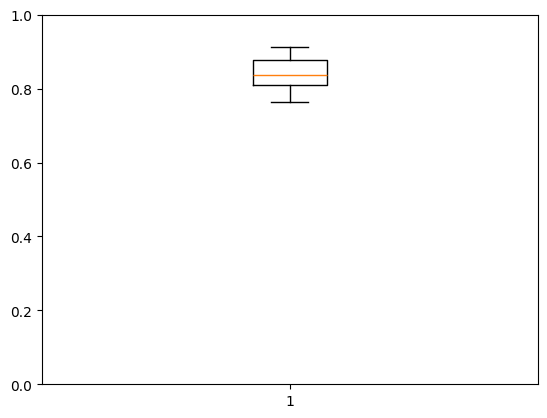

In [22]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(np.log(arr_1.mean(axis=0) + 1e-3), np.log(arr_2.mean(axis=0) + 1e-3))[0])) for res in nmf_res]
)
plt.ylim(0, 1)

(0.0, 1.0)

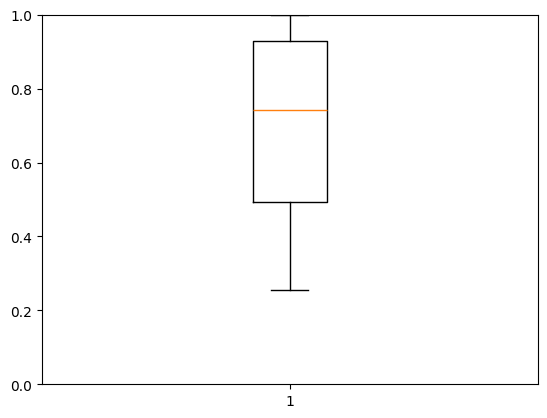

In [23]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(arr_1.mean(axis=0), arr_2.mean(axis=0))[0])) for res in nmf_res]
)
plt.ylim(0, 1)

In [15]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(arr_1.mean(axis=0), arr_2.mean(axis=0))[0])) for res in tangram_res],
)
plt.ylim(0, 1)

NameError: name 'tangram_res' is not defined

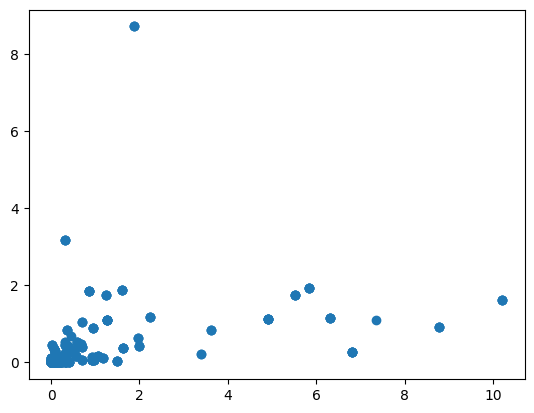

In [288]:
plt.scatter(
    np.hstack([res.original_counts.mean(axis=0) for res in tangram_res]),
    np.hstack([res.predicted_counts.mean(axis=0) for res in tangram_res]),
)

## Stem/TA

## Experimenting

In [329]:
def placeholder(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    base_genes: Sequence[str] | pd.Index,
    predicted_genes: Sequence[str] | pd.Index,
) -> tuple:

    (base_genes_query, predicted_genes_query), (base_genes_reference, predicted_genes_reference) = tuple(map(
        lambda adata: tuple(map(
            lambda genes: adata.var_names.get_indexer_for(genes), 
            (base_genes, predicted_genes))), (adata_query, adata_reference)))

    _, H_init, _ = non_negative_factorization(
        adata_reference[:, np.hstack([base_genes_reference, predicted_genes_reference])].X.toarray(), 
        n_components=n_components
    )
    W, _, _ = non_negative_factorization(
        adata_query[:, base_genes_query].X, 
        H=H_init[:, :len(base_genes)], 
        init="custom", 
        update_H=False,
        n_components=n_components
    )
    original_gene_counts = adata_query[:, predicted_genes].X.toarray()
    predicted_gene_counts = W @ H_init[:, -len(predicted_genes):]
    return original_gene_counts, predicted_gene_counts